In [1]:
%cd ..

/Users/ya.pristalov/Documents/skating-project/ai-skating-assistant


In [2]:
from src.dataset_builder import prepare_dataset
from src.config import VideoConfig, DataLoaderConfig
import matplotlib.pyplot as plt


In [3]:
SEED = 420

vc = VideoConfig(
    num_frames=32,
    target_fps=25,
    image_size=1024,
    return_meta=True,
)

dc = DataLoaderConfig(
    batch_size=1,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    seed=SEED,
)

In [4]:
df, dataset, dataloader = prepare_dataset(exclude_videos=[1], video_config=vc, data_config=dc)

def to_seconds(t):
    return t.hour * 3600 + t.minute * 60 + t.second

df["duration"] = df.apply(lambda row: (to_seconds(row["t_end_val"]) - to_seconds(row["t_start_val"])) + 1, axis=1) 

df

Videos in output dataset: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Parsed 493 timecodes for 10 unique videos


,video_id,jump_id,jump_type,rotations,underrotation,edge,fall,t_start_val,t_end_val,duration
0,2,0,T,4,ur,NaN,1,01:12:25,01:12:27,3
1,2,0,T,4,clean,NaN,0,01:26:26,01:26:28,3
2,2,0,T,4,ur,NaN,1,01:42:44,01:42:46,3
3,2,1,S,4,ur,NaN,1,00:18:13,00:18:15,3
4,2,1,S,4,ur,NaN,1,00:18:39,00:18:40,2
...,...,...,...,...,...,...,...,...,...,...
488,11,5,A,2,clean,NaN,0,00:51:39,00:51:41,3
489,11,5,A,2,clean,NaN,0,00:58:57,00:58:59,3
490,11,5,A,2,clean,NaN,0,01:04:44,01:04:46,3
491,11,5,A,2,clean,NaN,0,01:12:11,01:12:13,3


In [5]:
dataset

In [6]:
frames, labels, meta = next(iter(dataloader))
print(frames.shape)
print(labels)
print(meta)

/Users/ya.pristalov/Documents/skating-project/ai-skating-assistant/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


torch.Size([1, 32, 3, 1024, 1024])
tensor([5])
{'video_id': tensor([6]), 'jump_id': tensor([5]), 'jump_type': ['A'], 'start_sec': tensor([4274.], dtype=torch.float64), 'start_time': ['01:11:14'], 'end_sec': tensor([4277.], dtype=torch.float64), 'end_time': ['01:11:16'], 'indices': tensor([[106850, 106852, 106855, 106857, 106860, 106862, 106865, 106867, 106869,
         106872, 106874, 106877, 106879, 106881, 106884, 106886, 106889, 106891,
         106894, 106896, 106898, 106901, 106903, 106906, 106908, 106910, 106913,
         106915, 106918, 106920, 106923, 106925]]), 'path': ['data/videos/6.mp4'], 'fps': tensor([25.], dtype=torch.float64), 'total_frames': tensor([169076])}


In [7]:
import cv2

video = frames[0]  # (T, C, H, W)
video = video.permute(0, 2, 3, 1).cpu().numpy()  # (T, H, W, C)

T, H, W, C = video.shape

out = cv2.VideoWriter(
    "output.mp4",                          # файл
    cv2.VideoWriter_fourcc(*"mp4v"),       # кодек
    25,                                    # fps
    (W, H)                                 # размер (width, height)
)

for frame in video:
    frame = (frame * 255).astype("uint8")
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    cv2.imshow("sample", frame)

    out.write(frame)

    if cv2.waitKey(40) & 0xFF == ord("q"):
        break

out.release()
cv2.destroyAllWindows()

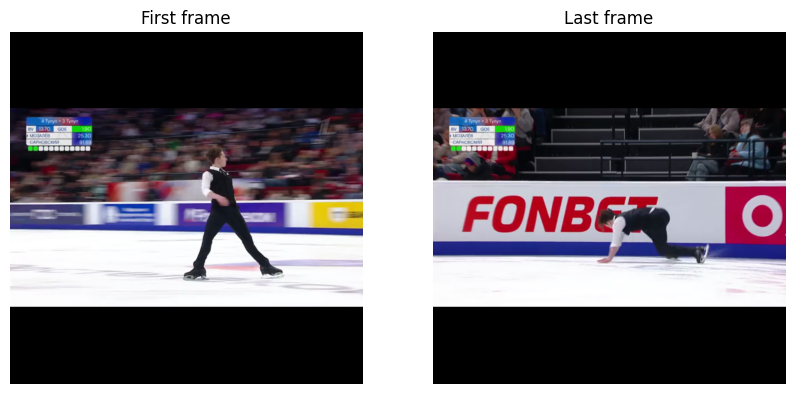

In [8]:


video = frames[0]  # (T, C, H, W)

first = video[0].permute(1, 2, 0).cpu().numpy()
last = video[-1].permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(first)
axes[0].set_title("First frame")
axes[0].axis("off")

axes[1].imshow(last)
axes[1].set_title("Last frame")
axes[1].axis("off")

plt.show()

In [9]:
raise ValueError()

ValueError: 

---

In [ ]:
from src.utils.downloaders import download_video

from pathlib import Path

In [ ]:
download_video("https://disk.360.yandex.ru/i/T2RHD9MoXTVdPA", "test_path.mkv", force_reload=False)

---

In [ ]:
from src.utils.xlsx_parser import parse_excel
import pandas as pd


In [ ]:
df = parse_excel("data/Разметка прыжков.xlsx")

In [ ]:
df

In [ ]:
df.info()

In [ ]:
df.groupby(["video_number", "jump_code"])[["start", "end"]].agg(["count"])

In [ ]:
df[["video_title"]].drop_duplicates()["video_title"].to_list()